<a href="https://colab.research.google.com/github/sabithakrishnan/timeseries-analysis/blob/main/timeseries_analysis_lightgbm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000552 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1051
[LightGBM] [Info] Number of data points in the train set: 7466, number of used features: 6
[LightGBM] [Info] Start training from score 10.815671
Test RMSE: 2.7554


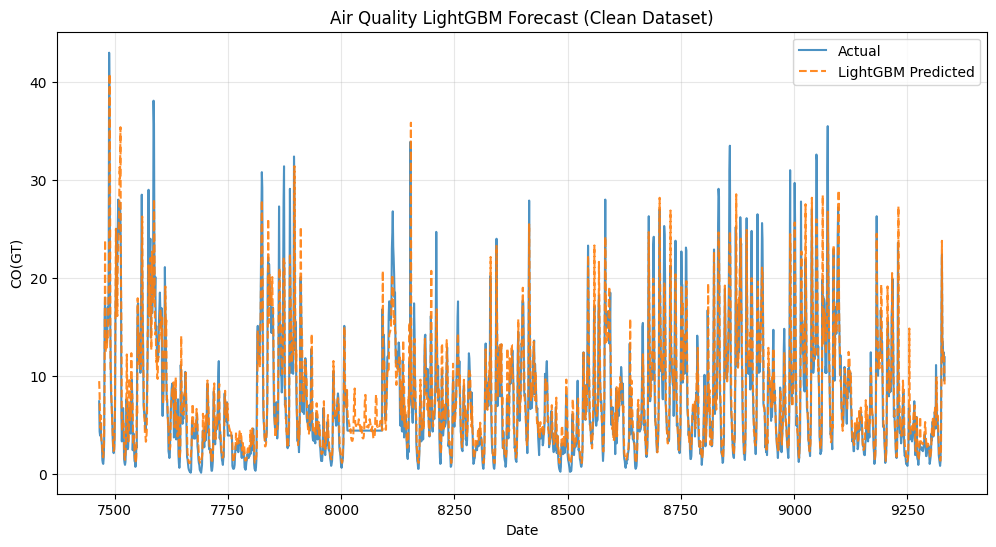

In [5]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

# 1. Load Data (Using the standard UCI Air Quality URL)
air_quality_df = pd.read_csv("/content/AirQualityUCI.csv", sep=";", decimal=",")
# Clean up empty rows and columns inherent to this specific dataset
air_quality_df = air_quality_df.dropna(how="all").dropna(axis=1, how="all")

# Combine Date and Time into a single datetime column and sort
air_quality_df["Datetime"] = pd.to_datetime(
    air_quality_df["Date"] + " " + air_quality_df["Time"], format="%d/%m/%Y %H.%M.%S"
)
air_quality_df = air_quality_df.sort_values("Datetime").reset_index(drop=True)

# Handle UCI missing value placeholders (-200) by replacing with NaN and forward-filling
air_quality_df = air_quality_df.replace(-200, np.nan)
air_quality_df = air_quality_df.ffill().bfill()

# Target: Predict Benzene (C6H6(GT)) concentrations
target = "C6H6(GT)"

# 2. Time Series Feature Engineering
# Create Lag features (previous 1, 2, and 24 hours)
air_quality_df["lag_1"] = air_quality_df[target].shift(1)
air_quality_df["lag_2"] = air_quality_df[target].shift(2)
air_quality_df["lag_24"] = air_quality_df[target].shift(24)

# Create Rolling Window features (4-hour moving average)
air_quality_df["rolling_mean_4"] = air_quality_df[target].shift(1).rolling(window=4).mean()

# Create Calendar features
air_quality_df["hour"] = air_quality_df["Datetime"].dt.hour
air_quality_df["day_of_week"] = air_quality_df["Datetime"].dt.dayofweek

# Drop rows with NaN values created by shifting
air_quality_df = air_quality_df.dropna().reset_index(drop=True)

# Define feature columns
features = ["lag_1", "lag_2", "lag_24", "rolling_mean_4", "hour", "day_of_week"]

# 3. Train/Test Split (Time-series aware)
# Reserve the last 20% of chronological data for final evaluation
split_idx = int(len(air_quality_df) * 0.8)
train_air_quality_df = air_quality_df.iloc[:split_idx]
test_air_quality_df = air_quality_df.iloc[split_idx:]

X_train, y_train = train_air_quality_df[features], train_air_quality_df[target]
X_test, y_test = test_air_quality_df[features], test_air_quality_df[target]

# 4. Initialize and Train LightGBM Regressor
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
)

# Fit model using a time-series validation strategy for early stopping
tscv = TimeSeriesSplit(n_splits=3)
model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)],
)

# 5. Predict and Evaluate
predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Test RMSE: {rmse:.4f}")
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual", color="tab:blue", alpha=0.8)
plt.plot(
    y_test.index,
    predictions,
    label="LightGBM Predicted",
    color="tab:orange",
    linestyle="--",
    alpha=0.9,
)
plt.title("Air Quality LightGBM Forecast (Clean Dataset)")
plt.xlabel("Date")
plt.ylabel("CO(GT)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()